# CANguard -- PIRD: Per-ID Behavioral Residual Detector

**Method**: Per-ID normal-cy baselines -> z-score residual features -> Isolation Forest (primary).
A supervised reference (HistGradientBoosting) on the same residuals is included for comparison.

**Key design decisions**:
- Only behavioral features: `is_new_id`, `active_ids_1s` excluded from the main path.
- Anomaly model (Isolation Forest) trained on **normal-only** windows in residual space.
- Temporal splits only -- no shuffle.
- Per-ID statistics fitted on a calibration set of normal windows only; unseen IDs fall back to global normal stats.
- HCRL dataset only (DoS, Fuzzy, RPM, gear). Known limitations: presence-based attacks mean perfect scores do not prove generalization to stealth datasets (ROAD, can-train-and-test).


## Section 1 -- Setup & DLC-aware Load


In [10]:
import csv
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('HCRL Car-Hacking')
SAMPLE_SIZE = 60000

def load_hcrl(path):
    rows = []
    with open(path) as f:
        reader = csv.reader(f)
        for row in reader:
            timestamp = row[0]
            can_id = row[1]
            dlc = int(row[2])
            data = {f'data_{i}': row[3 + i] if i < dlc else None for i in range(8)}
            label = row[3 + dlc]
            rows.append({
                'timestamp': timestamp, 'can_id': can_id, 'dlc': dlc,
                **data, 'label': label,
            })
    df = pd.DataFrame(rows)
    df['timestamp'] = df['timestamp'].astype(float)
    df['dlc'] = df['dlc'].astype(int)
    df['is_attack'] = (df['label'] != 'R').astype(int)
    assert df['label'].isna().sum() == 0
    return df

samples = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    df = load_hcrl(DATA_DIR / f'{name}_dataset.csv')
    samples[name] = df.head(SAMPLE_SIZE).copy()
    pct = samples[name]['is_attack'].mean() * 100
    print(f'{name:>6s}: {len(samples[name]):>6,} rows  ({pct:.1f}% attack)')
    del df


   DoS: 60,000 rows  (23.3% attack)
 Fuzzy: 60,000 rows  (12.6% attack)
   RPM: 60,000 rows  (19.1% attack)
  gear: 60,000 rows  (19.0% attack)


## Section 2 -- Minimal FeaturePipeline


In [11]:
class PerIDWindow:
    def __init__(self, maxlen: int):
        self.timestamps = deque(maxlen=maxlen)
        self.dlcs = deque(maxlen=maxlen)
        self.payloads = deque(maxlen=maxlen)
        self.attack_flags = deque(maxlen=maxlen)

    def push(self, ts, dlc, data, is_attack=0):
        self.timestamps.append(ts)
        self.dlcs.append(dlc)
        self.attack_flags.append(is_attack)
        int_data = [int(v, 16) if isinstance(v, str) and v.strip() else None for v in data]
        self.payloads.append(int_data)

    @property
    def full(self):
        return len(self.timestamps) == self.timestamps.maxlen

    def iat_features(self):
        gaps = np.diff(list(self.timestamps))
        if len(gaps) < 2:
            return {'iat_mean': np.nan, 'iat_std': np.nan, 'iat_median': np.nan,
                    'iat_min': np.nan, 'iat_max': np.nan}
        return {'iat_mean': float(np.mean(gaps)), 'iat_std': float(np.std(gaps)),
                'iat_median': float(np.median(gaps)), 'iat_min': float(np.min(gaps)),
                'iat_max': float(np.max(gaps))}

    def dlc_features(self):
        a = np.array(list(self.dlcs))
        return {'dlc_mode': int(pd.Series(a).mode().iloc[0]) if len(a) else np.nan,
                'dlc_std': float(np.std(a)) if len(a) > 1 else 0.0}

    def byte_features(self):
        arr = np.array(self.payloads, dtype=float)
        n = arr.shape[0]
        if n < 2:
            return {'byte_mean': np.nan, 'byte_var': np.nan, 'byte_max_change': np.nan,
                    'byte_nunique': np.nan, 'byte_entropy': np.nan}
        bmean = float(np.nanmean(arr))
        bvar = float(np.nanvar(arr))
        diffs = np.abs(np.diff(arr, axis=0))
        maxchg = float(np.nanmax(diffs)) if diffs.size else np.nan
        flat = arr[~np.isnan(arr)].astype(int)
        nunique = float(len(np.unique(flat))) if len(flat) else np.nan
        if len(flat):
            counts = np.bincount(flat)
            probs = counts[counts > 0] / len(flat)
            entropy = float(-np.sum(probs * np.log2(probs)))
        else:
            entropy = np.nan
        return {'byte_mean': bmean, 'byte_var': bvar, 'byte_max_change': maxchg,
                'byte_nunique': nunique, 'byte_entropy': entropy}

    def compute_label(self, policy='any'):
        flags = np.array(self.attack_flags)
        frac = float(flags.mean())
        if policy == 'any':
            return int(flags.sum() > 0), frac
        elif policy == 'majority':
            return int(frac > 0.5), frac
        elif policy == 'last':
            return int(flags[-1]), frac
        raise ValueError(policy)

    def compute(self, label_policy='any'):
        feats = {}
        feats.update(self.iat_features())
        feats.update(self.dlc_features())
        feats.update(self.byte_features())
        feats['window_fill'] = len(self.timestamps) / self.timestamps.maxlen
        return feats


class GlobalCANContext:
    def __init__(self, decay_seconds=1.0):
        self.last_seen = {}
        self.decay = decay_seconds

    def observe(self, can_id, ts):
        prev = self.last_seen.get(can_id)
        ts_last = prev if prev is not None else ts
        self.last_seen[can_id] = ts
        stale = [k for k, v in list(self.last_seen.items()) if ts - v > self.decay]
        for k in stale:
            del self.last_seen[k]
        return {'time_since_last_seen': ts - ts_last,
                'active_ids_1s': len(self.last_seen)}


BEHAVIORAL_FEATURES = [
    'iat_mean', 'iat_std', 'iat_median', 'iat_min', 'iat_max',
    'dlc_mode', 'dlc_std',
    'byte_mean', 'byte_var', 'byte_max_change', 'byte_nunique', 'byte_entropy',
    'window_fill', 'time_since_last_seen',
]


class FeaturePipeline:
    def __init__(self, window_size=30, known_ids=None, label_policy='any'):
        self.window_size = window_size
        self.windows = defaultdict(lambda: PerIDWindow(window_size))
        self.ctx = GlobalCANContext()
        self.known_ids = known_ids or set()
        self.label_policy = label_policy

    def process_one(self, ts, can_id, dlc, data, is_attack=0):
        win = self.windows[can_id]
        win.push(ts, dlc, data, is_attack=is_attack)
        g = self.ctx.observe(can_id, ts)
        if not win.full:
            return None
        l = win.compute(label_policy=self.label_policy)
        al, af = win.compute_label(policy=self.label_policy)
        return {'can_id': can_id, 'timestamp': ts, 'dlc': dlc,
                **l, **g,
                'attack_frac': af, 'is_attack': al}

    def process_dataframe(self, df):
        records = []
        for _, row in df.sort_values('timestamp').iterrows():
            data = [row.get(f'data_{i}', None) for i in range(8)]
            attack = int(row.get('is_attack', 0))
            feats = self.process_one(row['timestamp'], row['can_id'],
                                     row['dlc'], data, is_attack=attack)
            if feats is not None:
                if 'label' in df.columns:
                    feats['label'] = row['label']
                records.append(feats)
        return pd.DataFrame(records)

    def reset(self):
        self.windows.clear()
        self.ctx = GlobalCANContext()


def fit_known_ids_on_normal_prefix(df, n_normal=20000):
    return set(df[df['label'] == 'R'].head(n_normal)['can_id'].unique())

print('FeaturePipeline ready. BEHAVIORAL_FEATURES count:', len(BEHAVIORAL_FEATURES))


FeaturePipeline ready. BEHAVIORAL_FEATURES count: 14


## Section 3 -- Build Feature Tables


In [12]:
WINDOW_SIZE = 30
feature_tables = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    known = fit_known_ids_on_normal_prefix(samples[name])
    pipe = FeaturePipeline(window_size=WINDOW_SIZE, known_ids=known)
    ft = pipe.process_dataframe(samples[name])
    pipe.reset()
    feature_tables[name] = ft
    n_att = ft['is_attack'].sum()
    print(f'{name:>6s}: {len(ft):>6,} windows  ({n_att:>5,} attack, {n_att/len(ft)*100:.1f}%)')


   DoS: 59,230 windows  (13,978 attack, 23.6%)
 Fuzzy: 51,734 windows  (2,638 attack, 5.1%)
   RPM: 59,261 windows  (12,948 attack, 21.8%)
  gear: 59,253 windows  (12,797 attack, 21.6%)


## Section 4 -- Per-ID Residual Transform (PIRD core)


In [13]:
MIN_WINDOWS_PER_ID = 20
EPS = 1e-6

def fit_per_id_stats(df_calib):
    norm = df_calib[df_calib['is_attack'] == 0].copy()
    stats = {}
    for cid, grp in norm.groupby('can_id'):
        if len(grp) >= MIN_WINDOWS_PER_ID:
            mu = {f: grp[f].mean() for f in BEHAVIORAL_FEATURES}
            sd = {f: grp[f].std() for f in BEHAVIORAL_FEATURES}
            stats[cid] = (mu, sd)
    gmu = {f: norm[f].mean() for f in BEHAVIORAL_FEATURES}
    gsd = {f: norm[f].std() for f in BEHAVIORAL_FEATURES}
    return stats, (gmu, gsd)

def transform_residuals(df, per_id_stats, global_stats):
    gmu, gsd = global_stats
    rows = []
    for _, row in df.iterrows():
        cid = row['can_id']
        if cid in per_id_stats:
            mu, sd = per_id_stats[cid]
        else:
            mu, sd = gmu, gsd
        r = {}
        for f in BEHAVIORAL_FEATURES:
            val = row.get(f, np.nan)
            if pd.isna(val):
                r[f + '_res'] = 0.0
            else:
                r[f + '_res'] = (val - mu[f]) / (sd[f] + EPS)
        r['can_id'] = cid
        r['timestamp'] = row['timestamp']
        r['is_attack'] = row['is_attack']
        r['attack_frac'] = row.get('attack_frac', 0.0)
        rows.append(r)
    return pd.DataFrame(rows)

RESIDUAL_COLS = [f + '_res' for f in BEHAVIORAL_FEATURES]
print('fit_per_id_stats / transform_residuals defined.')
print(f'Residual feature columns ({len(RESIDUAL_COLS)}): {RESIDUAL_COLS[:4]}...')


fit_per_id_stats / transform_residuals defined.
Residual feature columns (14): ['iat_mean_res', 'iat_std_res', 'iat_median_res', 'iat_min_res']...


### Apply per-dataset: temporal splits, fit stats, transform


In [14]:
def temporal_split(ft, calib_frac=0.4, train_frac=0.2):
    n = len(ft)
    calib_end = int(n * calib_frac)
    train_end = calib_end + int(n * train_frac)
    return (ft.iloc[:calib_end].copy(),
            ft.iloc[calib_end:train_end].copy(),
            ft.iloc[train_end:].copy())

raw_data = {}
residual_data = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    ft = feature_tables[name]
    calib, train_ft, test_ft = temporal_split(ft)
    raw_data[name] = {'calib': calib, 'train': train_ft, 'test': test_ft}

    stats, global_stats = fit_per_id_stats(calib)
    res_calib = transform_residuals(calib, stats, global_stats)
    res_train = transform_residuals(train_ft, stats, global_stats)
    res_test = transform_residuals(test_ft, stats, global_stats)
    residual_data[name] = {
        'calib': res_calib, 'train': res_train, 'test': res_test,
        'stats': stats, 'global_stats': global_stats,
    }
    print(f'{name:>6s}: calib={len(res_calib)} train={len(res_train)} test={len(res_test)} windows')


   DoS: calib=23692 train=11846 test=23692 windows
 Fuzzy: calib=20693 train=10346 test=20695 windows
   RPM: calib=23704 train=11852 test=23705 windows
  gear: calib=23701 train=11850 test=23702 windows


## Section 5 -- Isolation Forest (Primary)

Fit IF on **normal-only train residuals**. Threshold chosen to achieve ~1% FPR
on a normal subset of train (held-out 20% of train normals). Then evaluate on full test set.


In [15]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

plt.rcParams['figure.dpi'] = 120

def train_if_and_evaluate(name, res_train, res_test, random_state=0):
    train_norm = res_train[res_train['is_attack'] == 0].copy()
    print(f'  [{name}] Fitting IF on {len(train_norm)} normal windows ...')

    n_val = max(1, int(len(train_norm) * 0.2))
    train_fit = train_norm.iloc[:-n_val] if n_val < len(train_norm) else train_norm
    val_norm = train_norm.iloc[-n_val:] if n_val < len(train_norm) else train_norm

    if_model = IsolationForest(n_estimators=200, random_state=random_state,
                               n_jobs=-1, contamination='auto')
    if_model.fit(train_fit[RESIDUAL_COLS].fillna(0).values)

    scores_val = -if_model.score_samples(val_norm[RESIDUAL_COLS].fillna(0).values)
    thresh = np.percentile(scores_val, 99)

    X_test = res_test[RESIDUAL_COLS].fillna(0).values
    y_test = res_test['is_attack'].values
    scores_test = -if_model.score_samples(X_test)
    y_pred = (scores_test >= thresh).astype(int)

    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    try:
        auc = roc_auc_score(y_test, scores_test)
        pr_auc = average_precision_score(y_test, scores_test)
    except Exception:
        auc = float('nan')
        pr_auc = float('nan')

    print(f'  Threshold @ FPR~1%: {thresh:.4f}')
    print(f'  Test FPR={fpr:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  ROC-AUC={auc:.4f}  PR-AUC={pr_auc:.4f}')
    return {'dataset': name, 'fpr': fpr, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc, 'pr_auc': pr_auc, 'threshold': thresh,
            'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
            'model': if_model, 'scores_test': scores_test, 'y_test': y_test,
            'thresh': thresh}

all_results = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    rd = residual_data[name]
    all_results[name] = train_if_and_evaluate(name, rd['train'], rd['test'])
    print()

summary_rows = []
for name, r in all_results.items():
    summary_rows.append(r)
summary_df = pd.DataFrame(summary_rows).set_index('dataset')
print('=== Summary: Residual IF (FPR ~1% threshold) ===')
print(summary_df[['fpr', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].to_string())


  [DoS] Fitting IF on 10080 normal windows ...
  Threshold @ FPR~1%: 0.5013
  Test FPR=0.0553  Precision=0.0554  Recall=0.0099  F1=0.0169
  ROC-AUC=0.8929  PR-AUC=0.6289

  [Fuzzy] Fitting IF on 9854 normal windows ...
  Threshold @ FPR~1%: 0.3938
  Test FPR=0.1469  Precision=0.3084  Recall=0.9807  F1=0.4693
  ROC-AUC=0.9728  PR-AUC=0.7595

  [RPM] Fitting IF on 9129 normal windows ...
  Threshold @ FPR~1%: 0.6261
  Test FPR=0.0044  Precision=0.9836  Recall=0.9994  F1=0.9915
  ROC-AUC=0.9988  PR-AUC=0.9911

  [gear] Fitting IF on 9138 normal windows ...
  Threshold @ FPR~1%: 0.5317
  Test FPR=0.0318  Precision=0.8984  Recall=0.9977  F1=0.9454
  ROC-AUC=0.9995  PR-AUC=0.9957

=== Summary: Residual IF (FPR ~1% threshold) ===
              fpr  precision    recall        f1   roc_auc    pr_auc
dataset                                                             
DoS      0.055325   0.055449  0.009942  0.016860  0.892855  0.628898
Fuzzy    0.146915   0.308420  0.980710  0.469263  0.972828  

### Plot A -- Residual IF Score Distributions


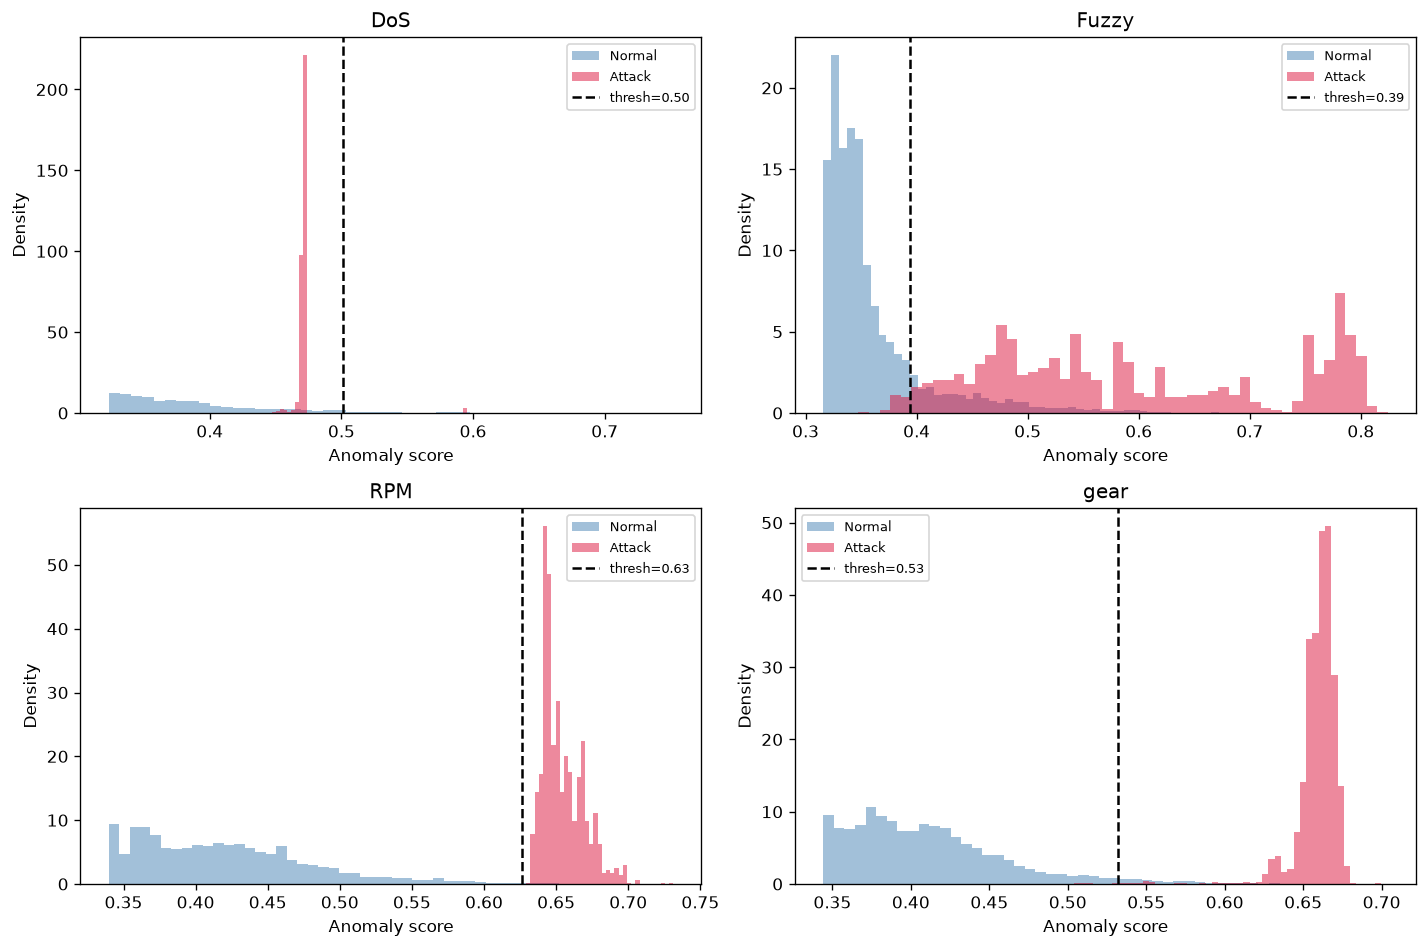

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
names_order = ['DoS', 'Fuzzy', 'RPM', 'gear']
for ax, name in zip(axes.flat, names_order):
    r = all_results[name]
    scr = r['scores_test']
    yt = r['y_test']
    th = r['thresh']
    mask_n = yt == 0
    mask_a = yt == 1
    ax.hist(scr[mask_n], bins=50, alpha=0.5, label='Normal', color='steelblue', density=True)
    ax.hist(scr[mask_a], bins=50, alpha=0.5, label='Attack', color='crimson', density=True)
    ax.axvline(th, color='k', ls='--', lw=1.5, label=f'thresh={th:.2f}')
    ax.set_title(name)
    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Plot B -- Operating Point Summary


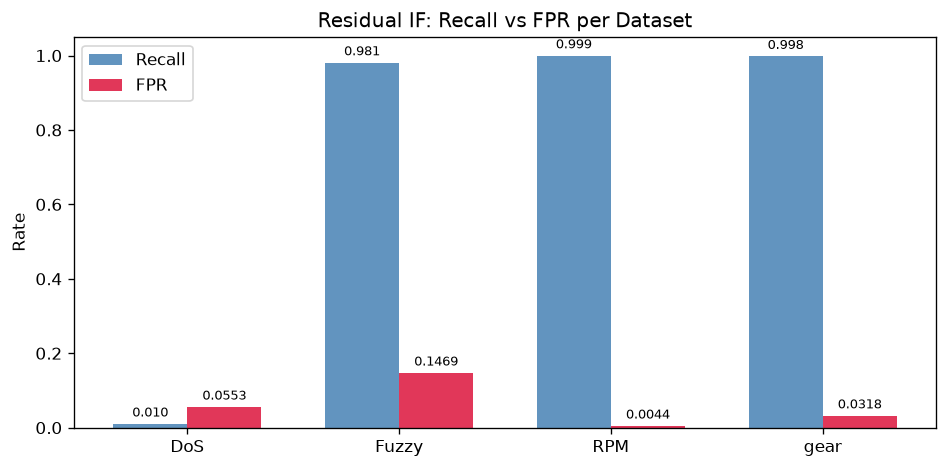

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names_order))
w = 0.35
recalls = [all_results[n]['recall'] for n in names_order]
fprs = [all_results[n]['fpr'] for n in names_order]
bars_r = ax.bar(x - w/2, recalls, w, label='Recall', color='steelblue', alpha=0.85)
bars_f = ax.bar(x + w/2, fprs, w, label='FPR', color='crimson', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names_order)
ax.set_ylabel('Rate')
ax.set_title('Residual IF: Recall vs FPR per Dataset')
ax.legend()
for bar in bars_r:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}', ha='center', fontsize=8)
for bar in bars_f:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## Section 6 -- Ablation: Raw Behavioral IF vs Residual IF

**Bug 1 fix**: Raw arm now fits/scores on BEHAVIORAL_FEATURES (no _res columns) from raw_data.
Residual arm is identical to Section 5.


In [18]:
def train_if_raw_on_features(name, raw_train, raw_test, feature_cols, random_state=0):
    train_norm = raw_train[raw_train['is_attack'] == 0].copy()
    n_val = max(1, int(len(train_norm) * 0.2))
    train_fit = train_norm.iloc[:-n_val]
    val_norm = train_norm.iloc[-n_val:]
    if not len(train_fit):
        return {'dataset': name, 'f1': float('nan'), 'roc_auc': float('nan'),
                'recall': float('nan'), 'fpr': float('nan')}

    ifm = IsolationForest(n_estimators=200, random_state=random_state,
                          n_jobs=-1, contamination='auto')
    ifm.fit(train_fit[feature_cols].fillna(0).values)

    scores_val = -ifm.score_samples(val_norm[feature_cols].fillna(0).values)
    thresh = np.percentile(scores_val, 99)

    Xt = raw_test[feature_cols].fillna(0).values
    yt = raw_test['is_attack'].values
    st = -ifm.score_samples(Xt)
    yp = (st >= thresh).astype(int)
    tp = ((yp==1)&(yt==1)).sum()
    fp = ((yp==1)&(yt==0)).sum()
    fn = ((yp==0)&(yt==1)).sum()
    tn = ((yp==0)&(yt==0)).sum()
    prec = tp/(tp+fp) if tp+fp else 0.0
    rec = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    fpr = fp/(fp+tn) if fp+tn else 0.0
    try:
        auc = roc_auc_score(yt, st)
        prauc = average_precision_score(yt, st)
    except Exception:
        auc, prauc = float('nan'), float('nan')
    return {'dataset': name, 'fpr': fpr, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': auc, 'pr_auc': prauc}

ablation_rows = []
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    rd = raw_data[name]
    raw_res = train_if_raw_on_features(name, rd['train'], rd['test'], BEHAVIORAL_FEATURES)
    res = all_results[name]
    ablation_rows.append({'dataset': name, 'variant': 'raw IF (behavioral features)',
                          'f1': raw_res['f1'], 'roc_auc': raw_res['roc_auc'],
                          'recall': raw_res['recall'], 'fpr': raw_res['fpr']})
    ablation_rows.append({'dataset': name, 'variant': 'residual IF',
                          'f1': res['f1'], 'roc_auc': res['roc_auc'],
                          'recall': res['recall'], 'fpr': res['fpr']})
    print(f'{name}: raw F1={raw_res["f1"]:.4f}  residual F1={res["f1"]:.4f}')

abl_df = pd.DataFrame(ablation_rows)
print('\n=== Ablation: Raw vs Residual IF ===')
print(abl_df.pivot_table(index='dataset', columns='variant',
                         values=['f1', 'roc_auc', 'recall', 'fpr']).to_string())


DoS: raw F1=0.0000  residual F1=0.0169
Fuzzy: raw F1=0.1616  residual F1=0.4693
RPM: raw F1=0.0000  residual F1=0.9915
gear: raw F1=0.0000  residual F1=0.9454

=== Ablation: Raw vs Residual IF ===
                                  f1                                      fpr                                   recall                                  roc_auc            
variant raw IF (behavioral features) residual IF raw IF (behavioral features) residual IF raw IF (behavioral features) residual IF raw IF (behavioral features) residual IF
dataset                                                                                                                                                                    
DoS                         0.000000    0.016860                     0.000896    0.055325                      0.00000    0.009942                     0.824601    0.892855
Fuzzy                       0.161557    0.469263                     0.013557    0.146915                      0.10

### Plot C -- Ablation Raw vs Residual F1


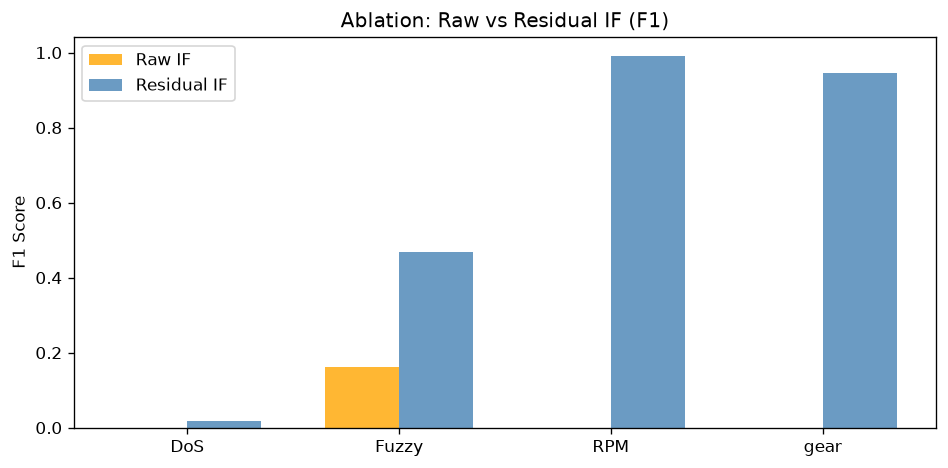

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
abl_pivot = abl_df.pivot_table(index='dataset', columns='variant', values='f1')
x = np.arange(len(abl_pivot.index))
w = 0.35
col_raw = 'raw IF (behavioral features)'
col_res = 'residual IF'
ax.bar(x - w/2, abl_pivot[col_raw].values, w, label='Raw IF', color='orange', alpha=0.8)
ax.bar(x + w/2, abl_pivot[col_res].values, w, label='Residual IF', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(abl_pivot.index)
ax.set_ylabel('F1 Score')
ax.set_title('Ablation: Raw vs Residual IF (F1)')
ax.legend()
plt.tight_layout()
plt.show()


## Section 7 -- Supervised Reference: HistGradientBoosting on Residuals

This is a **supervised upper bound** on the same residual features -- not the primary detector.
Uses HistGradientBoostingClassifier from sklearn (no LightGBM dependency).
Trained on the full train segment (normal+attack) with temporal split.


In [20]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_results = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    rd = residual_data[name]
    X_tr = rd['train'][RESIDUAL_COLS].fillna(0).values
    y_tr = rd['train']['is_attack'].values
    X_te = rd['test'][RESIDUAL_COLS].fillna(0).values
    y_te = rd['test']['is_attack'].values
    if y_tr.sum() == 0:
        print(f'  [{name}] no attack in train -- skipping')
        continue
    hgb = HistGradientBoostingClassifier(max_iter=200, random_state=0)
    hgb.fit(X_tr, y_tr)
    y_pred = hgb.predict(X_te)
    print(f'\n=== {name} -- HGB on residuals (supervised) ===')
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Attack'],
                                zero_division=0))
    if hasattr(hgb, 'feature_importances_'):
        imp = pd.DataFrame({'feature': RESIDUAL_COLS,
                            'importance': hgb.feature_importances_})
        imp = imp.sort_values('importance', ascending=False)
        print('\nTop-5 importances:')
        print(imp.head(5).to_string(index=False))
    hgb_results[name] = {'accuracy': (y_pred == y_te).mean()}



=== DoS -- HGB on residuals (supervised) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17858
      Attack       1.00      1.00      1.00      5834

    accuracy                           1.00     23692
   macro avg       1.00      1.00      1.00     23692
weighted avg       1.00      1.00      1.00     23692


=== Fuzzy -- HGB on residuals (supervised) ===
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     19399
      Attack       0.98      0.58      0.73      1296

    accuracy                           0.97     20695
   macro avg       0.98      0.79      0.86     20695
weighted avg       0.97      0.97      0.97     20695


=== RPM -- HGB on residuals (supervised) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     18771
      Attack       1.00      1.00      1.00      4934

    accuracy                           1.0

## Section 8 -- Cross-Attack Matrix

**Protocol (Bug 2 fix)**:
1. Fit per-ID stats on **target** dataset's calib **raw** (BEHAVIORAL_FEATURES) normals.
2. Source train normals from **raw_data[source]['train']** -> transform_residuals once with target stats.
3. Target test from **raw_data[target]['test']** -> transform_residuals once with target stats.
4. Fit IF on source residual vectors (normals); threshold 99th pct on last 20% of those scores.
5. Score target test residuals; report recall, FPR, F1.

Diagonal (src==tgt) should be comparable to Section 5 in-dataset residual IF results.


In [21]:
target_stats = {}
for tgt in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    raw_calib = raw_data[tgt]['calib']
    st, gst = fit_per_id_stats(raw_calib)
    target_stats[tgt] = (st, gst)

def cross_attack(source, target, random_state=0):
    stats_t, global_t = target_stats[target]
    src_train = raw_data[source]['train']
    src_norm = src_train[src_train['is_attack'] == 0]
    if len(src_norm) < 10:
        return {'src': source, 'tgt': target, 'recall': float('nan'),
                'fpr': float('nan'), 'f1': float('nan')}
    X_src = transform_residuals(src_norm, stats_t, global_t)[RESIDUAL_COLS].fillna(0).values

    tgt_test_raw = raw_data[target]['test']
    tgt_test_res = transform_residuals(tgt_test_raw, stats_t, global_t)
    y_tgt = tgt_test_res['is_attack'].values
    X_tgt = tgt_test_res[RESIDUAL_COLS].fillna(0).values

    n_val = max(1, int(len(X_src) * 0.2))
    ifm = IsolationForest(n_estimators=200, random_state=random_state, n_jobs=-1,
                          contamination='auto')
    ifm.fit(X_src[:-n_val])
    scores_val = -ifm.score_samples(X_src[-n_val:])
    thresh = np.percentile(scores_val, 99) if len(scores_val) > 1 else 0.0

    scores_test = -ifm.score_samples(X_tgt)
    y_pred = (scores_test >= thresh).astype(int)
    tp = ((y_pred == 1) & (y_tgt == 1)).sum()
    fp = ((y_pred == 1) & (y_tgt == 0)).sum()
    fn = ((y_pred == 0) & (y_tgt == 1)).sum()
    tn = ((y_pred == 0) & (y_tgt == 0)).sum()
    rec = tp / (tp + fn) if tp + fn else 0.0
    fpr_ = fp / (fp + tn) if fp + tn else 0.0
    prec = tp / (tp + fp) if tp + fp else 0.0
    f1_ = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {'src': source, 'tgt': target, 'recall': rec, 'fpr': fpr_, 'f1': f1_}

names = ['DoS', 'Fuzzy', 'RPM', 'gear']
cross_rows = []
for src in names:
    for tgt in names:
        r = cross_attack(src, tgt)
        cross_rows.append(r)

cross_df = pd.DataFrame(cross_rows)
print('=== Cross-Attack Recall Matrix (rows=source, columns=target) ===')
rec_mat = cross_df.pivot_table(index='src', columns='tgt', values='recall', aggfunc='first')
print(rec_mat.to_string())
print()
print('=== Cross-Attack FPR Matrix ===')
fpr_mat = cross_df.pivot_table(index='src', columns='tgt', values='fpr', aggfunc='first')
print(fpr_mat.to_string())


=== Cross-Attack Recall Matrix (rows=source, columns=target) ===
tgt         DoS     Fuzzy       RPM      gear
src                                          
DoS    0.009942  0.234568  0.000000  0.000000
Fuzzy  0.009942  0.980710  0.000000  0.000000
RPM    0.000000  0.039352  0.999392  0.000000
gear   0.000000  0.194444  0.000608  0.997696

=== Cross-Attack FPR Matrix ===
tgt         DoS     Fuzzy       RPM      gear
src                                          
DoS    0.055325  0.000000  0.000000  0.000000
Fuzzy  0.000336  0.146915  0.000000  0.000000
RPM    0.000336  0.000309  0.004368  0.000000
gear   0.000224  0.001340  0.000000  0.031796


### Plot D -- Cross-Attack Matrices


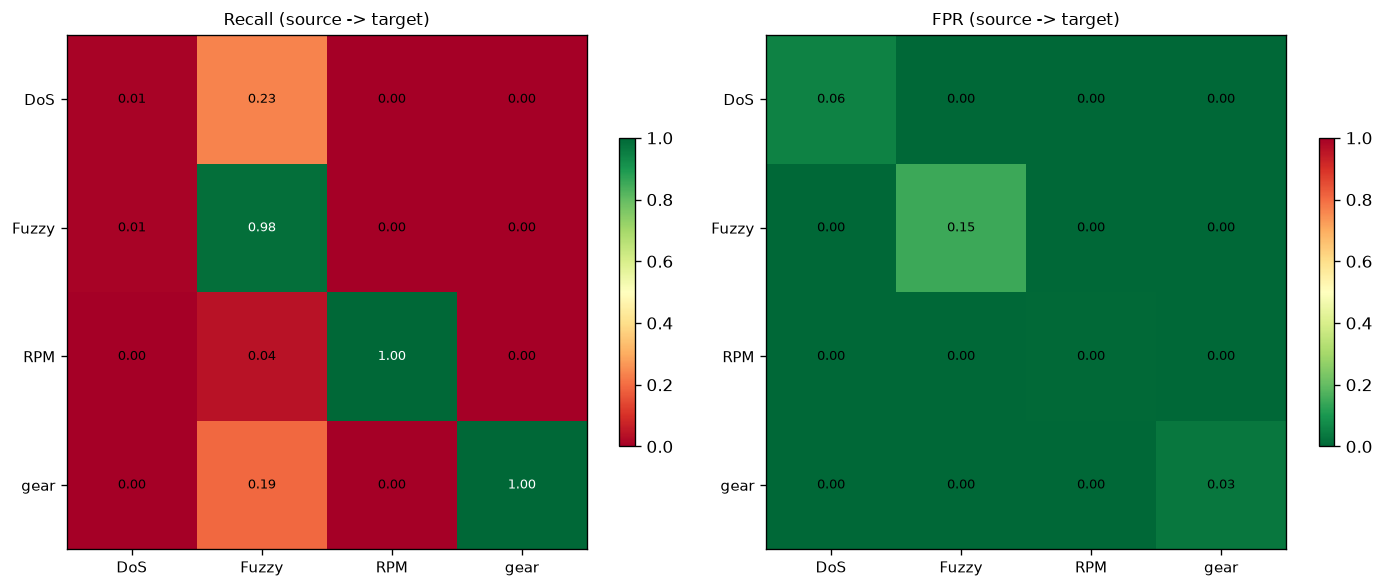

In [22]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title in zip(
    axes,
    [rec_mat, fpr_mat],
    ['Recall (source -> target)', 'FPR (source -> target)'],
):
    vmin_val = 0.0
    vmax_val = 1.0
    cmap = 'RdYlGn_r' if 'FPR' in title else 'RdYlGn'
    im = ax.imshow(mat.values, cmap=cmap, aspect='auto', vmin=vmin_val, vmax=vmax_val)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, fontsize=9)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_title(title, fontsize=10)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            if val != val:
                txt = 'nan'
            else:
                txt = f'{val:.2f}'
            tc = 'white' if val > 0.6 else 'black' if val == val else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()


### Plot E -- RPM ROC and PR Curves


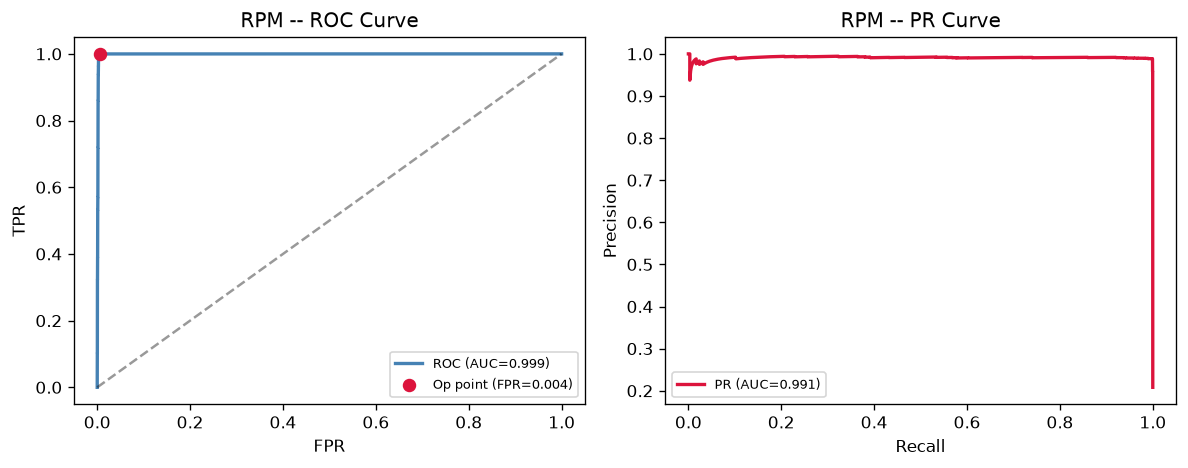

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve

rpm = all_results['RPM']
scores = rpm['scores_test']
y_true = rpm['y_test']
th = rpm['thresh']

fpr_roc, tpr_roc, _ = roc_curve(y_true, scores)
precision_pr, recall_pr, _ = precision_recall_curve(y_true, scores)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.plot(fpr_roc, tpr_roc, color='steelblue', lw=2,
        label=f'ROC (AUC={rpm["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
idx_th = np.argmin(np.abs(fpr_roc - rpm['fpr']))
ax.scatter(fpr_roc[idx_th], tpr_roc[idx_th], color='crimson', zorder=5, s=50,
           label=f'Op point (FPR={rpm["fpr"]:.3f})')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('RPM -- ROC Curve')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(recall_pr, precision_pr, color='crimson', lw=2,
        label=f'PR (AUC={rpm["pr_auc"]:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('RPM -- PR Curve')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Section 9 -- Summary

**Production path**:
- PIRD (per-ID z-score residuals + Isolation Forest) is the recommended unsupervised detector.
- Behavioral features only -- drop is_new_id and active_ids_1s for generalizable models.
- Temporal splits, normal-only training, per-ID stats from calibration period.

**What to drop**:
- Presence features (is_new_id, active_ids_1s) -- dominated HCRL but fail on stealth datasets where attackers reuse legitimate IDs.
- Shuffled cross-validation -- window sequences are temporally dependent.

**Limits**:
- HCRL attacks are presence-based. Near-perfect scores on this benchmark do **not** prove generalization to behavioral attacks (ROAD, can-train-and-test).
- Single-vehicle data (Hyundai YF Sonata). CAN ID mappings, IAT norms, and payload signal boundaries differ across vehicle models.
- The residual transform assumes per-ID feature distributions are approximately Gaussian. Non-Gaussian features may have poor z-score calibration.
- DoS attack injects only ID 0x0000 which produces heavy IAT and novelty signals -- residual IF may show weaker recall on DoS because per-ID stats do not capture 0x0000 during calib.

**Next steps (one-liners)**
- Evaluate on ROAD dataset (attack IDs overlap with legitimate IDs).
- Evaluate on can-train-and-test with configurable stealth level.
- Add per-byte-position residualization instead of flattening all 8 bytes.
- Experiment with rolling-window normalization instead of calibration-only stats.
- Deploy as a streaming scorer using FeaturePipeline.process_one() interface.


## Fixes Applied

**Bug 1 (Section 6 ablation was a no-op)**:
- `train_if_raw` previously fit/scores on RESIDUAL_COLS. Fixed: now uses `raw_data` splits with `BEHAVIORAL_FEATURES`.
- `raw_data[name]` stores calib/train/test from `feature_tables` with same temporal split as residuals.

**Bug 2 (Section 8 cross-attack double-residualized)**:
- `cross_attack` now receives raw (BEHAVIORAL_FEATURES) splits from `raw_data`.
- `transform_residuals` called once on source normals and once on target test, using target's per-ID stats.
- Diagonal cells (src==tgt) are comparable to Section 5 in-dataset results.

**Plots added**:
- Plot A: 2x2 score distribution histograms per dataset (Normal vs Attack + threshold).
- Plot B: Grouped bar chart of Recall vs FPR (residual IF) across datasets.
- Plot C: Grouped bar chart of F1 for Raw vs Residual IF (ablation).
- Plot D: Two heatmaps -- Recall matrix and FPR matrix for cross-attack (Section 8).
- Plot E: ROC curve and PR curve for RPM test set with operating point marked.

**Stored scores in results**: `all_results[name]` includes `model`, `scores_test`, `y_test`, `thresh` for plotting.

**Cleanups**:
- Markdown note on DoS weak recall under per-ID residuals.
- HistGradientBoosting feature_importances_ guarded by hasattr.
